Esta es la versión v2 prometida, con la direccion del analisis chi2 filtrada. Vamos a ver que tal funciona el algoritmo ahora

In [1]:
import pandas as pd
import re
import html

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = html.unescape(text)
    text = re.sub(r"\[deleted\]", " ", text, flags=re.IGNORECASE)
    text = re.sub(r"\[removed\]", " ", text, flags=re.IGNORECASE)
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"[^a-zA-Z0-9\s']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text.lower()

BASE = "D:\\TFM\\data\\"
files = {
    "overwatch": "Overwatch.corpus\\overwatch_posts_final.parquet",
    "gaming": "gaming.corpus\\gaming_posts_final.parquet",
    "hard_neg": "GlobalOffensive.corpus\\GlobalOffensive_posts_final.parquet",
    "soft_neg": "NoStupidQuestions.corpus\\NoStupidQuestions_posts_final.parquet",
}

dfs = {}
for key, fname in files.items():
    df = pd.read_parquet(BASE + fname)
    df["clean_text"] = df["full_text"].apply(clean_text)
    dfs[key] = df
    print(f"{key:10s} -> {len(df):,} filas | vacíos tras limpieza: {(df['clean_text']=='').sum()}")

overwatch  -> 300,000 filas | vacíos tras limpieza: 327
gaming     -> 300,000 filas | vacíos tras limpieza: 911
hard_neg   -> 300,000 filas | vacíos tras limpieza: 356
soft_neg   -> 300,000 filas | vacíos tras limpieza: 22


A continuación corregimos el error de dirección en la siguiente celda:

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.feature_selection import chi2
import numpy as np
import pandas as pd

custom_stopwords = {
    "like", "just", "really", "also", "get", "got", "would", "could",
    "one", "even", "much", "still", "make", "made", "know", "think",
    "https", "http", "www", "reddit", "com",
    "im", "ive", "dont", "didnt", "isnt", "youre", "theyre",
}
extended_stopwords = list(ENGLISH_STOP_WORDS.union(custom_stopwords))

def chi2_vs_negative_with_direction(df_target, df_negative, ngram_range=(1, 2), min_df=5, max_df=0.6):
    df_pair = pd.concat([df_target, df_negative], ignore_index=True)
    n_target = len(df_target)
    y = np.array([1] * n_target + [0] * len(df_negative))

    vec = TfidfVectorizer(stop_words=extended_stopwords, ngram_range=ngram_range, min_df=min_df, max_df=max_df)
    X = vec.fit_transform(df_pair["clean_text"])
    scores, pvals = chi2(X, y)
    terms = np.array(vec.get_feature_names_out())

    # Frecuencia documental por clase (presencia binaria, no TF-IDF)
    X_binary = (X > 0).astype(int)
    X_target = X_binary[:n_target]
    X_neg = X_binary[n_target:]

    freq_target = np.asarray(X_target.mean(axis=0)).ravel()  # % de docs de OW que contienen el término
    freq_neg = np.asarray(X_neg.mean(axis=0)).ravel()        # % de docs del negativo que lo contienen

    direction_ok = freq_target > freq_neg  # True = asociado positivamente a Overwatch

    return pd.DataFrame({
        "term": terms,
        "chi2": scores,
        "pval": pvals,
        "freq_target": freq_target,
        "freq_negative": freq_neg,
        "direction_ok": direction_ok,
    }).set_index("term")


res_soft   = chi2_vs_negative_with_direction(dfs["overwatch"], dfs["soft_neg"])
res_medium = chi2_vs_negative_with_direction(dfs["overwatch"], dfs["gaming"])
res_hard   = chi2_vs_negative_with_direction(dfs["overwatch"], dfs["hard_neg"])

common_terms = res_soft.index.intersection(res_medium.index).intersection(res_hard.index)
print(f"Términos comunes (antes de filtrar dirección): {len(common_terms):,}")

combined = pd.DataFrame({
    "chi2_soft":   res_soft.loc[common_terms, "chi2"],
    "chi2_medium": res_medium.loc[common_terms, "chi2"],
    "chi2_hard":   res_hard.loc[common_terms, "chi2"],
    "pval_soft":   res_soft.loc[common_terms, "pval"],
    "pval_medium": res_medium.loc[common_terms, "pval"],
    "pval_hard":   res_hard.loc[common_terms, "pval"],
    "dir_soft":    res_soft.loc[common_terms, "direction_ok"],
    "dir_medium":  res_medium.loc[common_terms, "direction_ok"],
    "dir_hard":    res_hard.loc[common_terms, "direction_ok"],
})

combined["chi2_min"] = combined[["chi2_soft", "chi2_medium", "chi2_hard"]].min(axis=1)

significativo = (
    (combined["pval_soft"] < 0.05) & (combined["pval_medium"] < 0.05) & (combined["pval_hard"] < 0.05)
)
direccion_correcta = combined["dir_soft"] & combined["dir_medium"] & combined["dir_hard"]

final_terms_v2 = combined[significativo & direccion_correcta].sort_values("chi2_min", ascending=False)

print(f"Términos finales (sig. + dirección correcta): {len(final_terms_v2):,}")
print(f"Términos descartados por dirección incorrecta: {(significativo & ~direccion_correcta).sum():,}")

final_terms_v2.to_parquet("D:\\TFM\\data\\chi2_overwatch_terms_v2.parquet")

Términos comunes (antes de filtrar dirección): 203,574
Términos finales (sig. + dirección correcta): 13,282
Términos descartados por dirección incorrecta: 1,323


In [5]:
descartados = combined[significativo & ~direccion_correcta].sort_values("chi2_min", ascending=False)
print(descartados.head(20)[["chi2_min", "freq_target" if "freq_target" in descartados.columns else "chi2_min"]])

               chi2_min    chi2_min
term                               
ps4          338.347334  338.347334
game         326.511982  326.511982
people       271.403207  271.403207
matchmaking  253.139659  253.139659
xbox         244.890973  244.890973
games        187.013732  187.013732
don          180.486637  180.486637
rank         171.597488  171.597488
2018         166.698930  166.698930
battle       155.243525  155.243525
round        138.704422  138.704422
flick        132.055237  132.055237
pc           123.400217  123.400217
c9           121.212347  121.212347
map          118.660200  118.660200
uk           113.032361  113.032361
76           111.511967  111.511967
gameplay     105.548400  105.548400
feel         100.361466  100.361466
sites         99.616908   99.616908


Vemos que han sido descartados muchos términos que fueron incluidos en nuestro set de terminos v1 por la falta de consideración de la direccion del analisis chi2

## Evaluación del algoritmo contra Gold Set etiquetado

Ahora vamos a evaluar nuestro algoritmo de scoring contra el gold set que ya ha sido etiquetado manualmente.

In [6]:
import pandas as pd
import numpy as np
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_curve, auc,
    precision_recall_curve, f1_score, accuracy_score, roc_auc_score
)
import matplotlib.pyplot as plt

# Cargar gold set etiquetado
gold_labeled = pd.read_csv("D:\\TFM\\data\\gold_set_labeled.csv")

print(f"Total registros en gold set: {len(gold_labeled)}")
print(f"\nDistribución de etiquetas:")
print(gold_labeled["manual_label"].value_counts().sort_index())
print(f"  0 = No habla de Overwatch")
print(f"  1 = Sí habla de Overwatch")
print(f"  2 = Contexto insuficiente")
print(f"  3 = Texto no usable")

Total registros en gold set: 380

Distribución de etiquetas:
manual_label
0    241
1     87
2     15
3     37
Name: count, dtype: int64
  0 = No habla de Overwatch
  1 = Sí habla de Overwatch
  2 = Contexto insuficiente
  3 = Texto no usable


In [7]:
# Reconstruir función de limpieza y scoring con el vocabulario loadado previamente
import re

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = html.unescape(text)
    text = re.sub(r"\[deleted\]", " ", text, flags=re.IGNORECASE)
    text = re.sub(r"\[removed\]", " ", text, flags=re.IGNORECASE)
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"[^a-zA-Z0-9\s']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text.lower()

# Cargar términos finales y crear patrón
final_terms = pd.read_parquet("D:\\TFM\\data\\chi2_overwatch_terms_v2.parquet")
term_weights = final_terms["chi2_min"].to_dict()

sorted_terms = sorted(term_weights.keys(), key=len, reverse=True)
pattern = re.compile(r"\b(" + "|".join(re.escape(t) for t in sorted_terms) + r")\b")

def score_text(text, weights=term_weights, min_words_norm=5):
    text_clean = clean_text(text)
    matches = pattern.findall(text_clean)
    if not matches:
        return 0.0, []
    raw_score = sum(weights[m] for m in matches)
    n_words = max(len(text_clean.split()), min_words_norm)
    return raw_score / n_words, matches

# Aplicar scoring al gold set
scores_matches = gold_labeled["full_text"].apply(score_text)
gold_labeled["score"] = scores_matches.apply(lambda x: x[0])
gold_labeled["matched_terms"] = scores_matches.apply(lambda x: x[1])

print(f"\nEstadísticas de score en gold set:")
print(gold_labeled["score"].describe())


Estadísticas de score en gold set:
count    380.000000
mean      22.302988
std       77.464368
min        0.000000
25%        0.000000
50%        1.188811
75%        7.304743
max      851.247536
Name: score, dtype: float64


In [8]:
# Filtrar casos "usables": solo etiquetas 0 y 1 (excluir 2=contexto insuficiente, 3=no usable)
gold_usable = gold_labeled[gold_labeled["manual_label"].isin([0, 1])].copy()

print(f"Total registros usables: {len(gold_usable)}")
print(f"Distribución de clases en conjunto usable:")
print(f"  Clase 0 (No Overwatch): {(gold_usable['manual_label']==0).sum()}")
print(f"  Clase 1 (Sí Overwatch): {(gold_usable['manual_label']==1).sum()}")

# Variable target
y_true = gold_usable["manual_label"].values

Total registros usables: 328
Distribución de clases en conjunto usable:
  Clase 0 (No Overwatch): 241
  Clase 1 (Sí Overwatch): 87


In [9]:
# Calcular ROC y encontrar umbral óptimo
y_scores = gold_usable["score"].values

# ROC curve
fpr, tpr, thresholds = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

# Precision-recall curve
precision, recall, pr_thresholds = precision_recall_curve(y_true, y_scores)

# Encontrar umbral óptimo (max F1)
f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-10)
optimal_idx = np.argmax(f1_scores)
optimal_threshold = pr_thresholds[optimal_idx]
optimal_f1 = f1_scores[optimal_idx]

print(f"ROC-AUC Score: {roc_auc:.4f}")
print(f"\nUmbral óptimo (máximo F1): {optimal_threshold:.4f}")
print(f"F1 Score en umbral óptimo: {optimal_f1:.4f}")

ROC-AUC Score: 0.8660

Umbral óptimo (máximo F1): 11.4444
F1 Score en umbral óptimo: 0.6792


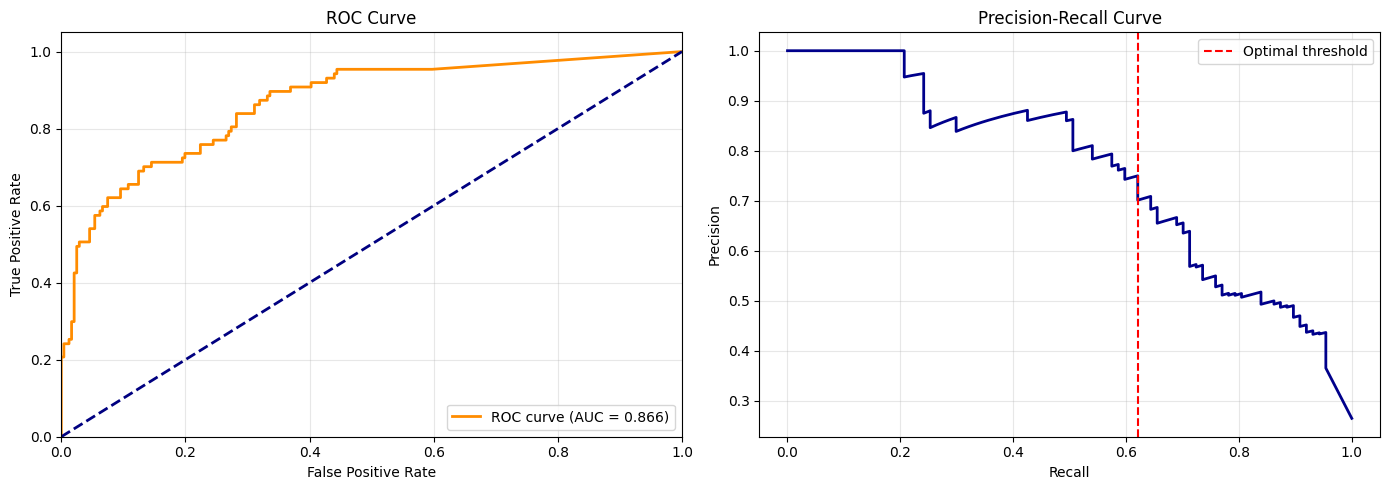

Gráficas generadas.


In [10]:
# Visualizar ROC y Precision-Recall curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend(loc="lower right")
axes[0].grid(alpha=0.3)

# Precision-Recall Curve
axes[1].plot(recall, precision, color='darkblue', lw=2)
axes[1].axvline(x=recall[optimal_idx] if optimal_idx < len(recall) else 0.5, color='red', linestyle='--', label=f'Optimal threshold')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Gráficas generadas.")

In [11]:
# Evaluar con diferentes umbrales
def evaluate_threshold(y_true, y_scores, threshold):
    y_pred = (y_scores >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    return {
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": tp / (tp + fp) if (tp + fp) > 0 else 0,
        "recall": tp / (tp + fn) if (tp + fn) > 0 else 0,
        "f1": f1_score(y_true, y_pred),
        "tp": tp, "fp": fp, "tn": tn, "fn": fn,
    }

# Probar múltiples umbrales
# alternativa más robusta a outliers: percentiles de la distribución real
thresholds_test = np.percentile(y_scores, np.linspace(0, 100, 50))
results = [evaluate_threshold(y_true, y_scores, t) for t in thresholds_test]
results_df = pd.DataFrame(results)

print("\n" + "="*100)
print("MÉTRICAS CON DIFERENTES UMBRALES")
print("="*100)
print(results_df.to_string(index=False))

# Mostrar el mejor umbral por F1
best_f1_idx = results_df["f1"].idxmax()
best_result = results_df.loc[best_f1_idx]
print(f"\n{'Mejor umbral (F1):':<20} {best_result['threshold']:.3f}")
print(f"{'Accuracy:':<20} {best_result['accuracy']:.4f}")
print(f"{'Precision:':<20} {best_result['precision']:.4f}")
print(f"{'Recall:':<20} {best_result['recall']:.4f}")
print(f"{'F1 Score:':<20} {best_result['f1']:.4f}")


MÉTRICAS CON DIFERENTES UMBRALES
 threshold  accuracy  precision   recall       f1  tp  fp  tn  fn
  0.000000  0.265244   0.265244 1.000000 0.419277  87 241   0   0
  0.000000  0.265244   0.265244 1.000000 0.419277  87 241   0   0
  0.000000  0.265244   0.265244 1.000000 0.419277  87 241   0   0
  0.000000  0.265244   0.265244 1.000000 0.419277  87 241   0   0
  0.000000  0.265244   0.265244 1.000000 0.419277  87 241   0   0
  0.000000  0.265244   0.265244 1.000000 0.419277  87 241   0   0
  0.000000  0.265244   0.265244 1.000000 0.419277  87 241   0   0
  0.000000  0.265244   0.265244 1.000000 0.419277  87 241   0   0
  0.000000  0.265244   0.265244 1.000000 0.419277  87 241   0   0
  0.000000  0.265244   0.265244 1.000000 0.419277  87 241   0   0
  0.000000  0.265244   0.265244 1.000000 0.419277  87 241   0   0
  0.000000  0.265244   0.265244 1.000000 0.419277  87 241   0   0
  0.000000  0.265244   0.265244 1.000000 0.419277  87 241   0   0
  0.000000  0.265244   0.265244 1.000000 0

In [12]:
# Análisis detallado con el umbral óptimo
optimal_threshold = best_result["threshold"]
y_pred_optimal = (y_scores >= optimal_threshold).astype(int)

print(f"\n{'='*100}")
print(f"ANÁLISIS DETALLADO CON UMBRAL ÓPTIMO: {optimal_threshold:.3f}")
print(f"{'='*100}")

# Matriz de confusión
cm = confusion_matrix(y_true, y_pred_optimal)
print("\nMatriz de Confusión:")
print(f"                Predicción: No Overwatch  |  Predicción: Sí Overwatch")
print(f"Etiqueta: No Overwatch     {cm[0,0]:>6d}           |  {cm[0,1]:>6d}")
print(f"Etiqueta: Sí Overwatch     {cm[1,0]:>6d}           |  {cm[1,1]:>6d}")

# Classification report
print("\n" + classification_report(y_true, y_pred_optimal, 
                                 target_names=["No Overwatch", "Sí Overwatch"]))

# Guardar predicciones
gold_usable["pred_score"] = y_scores
gold_usable["pred_label"] = y_pred_optimal
gold_usable["correct"] = (gold_usable["pred_label"] == gold_usable["manual_label"]).astype(int)

print(f"\nPredicciones correctas: {gold_usable['correct'].sum()} de {len(gold_usable)} ({100*gold_usable['correct'].mean():.2f}%)")


ANÁLISIS DETALLADO CON UMBRAL ÓPTIMO: 5.703

Matriz de Confusión:
                Predicción: No Overwatch  |  Predicción: Sí Overwatch
Etiqueta: No Overwatch        208           |      33
Etiqueta: Sí Overwatch         26           |      61

              precision    recall  f1-score   support

No Overwatch       0.89      0.86      0.88       241
Sí Overwatch       0.65      0.70      0.67        87

    accuracy                           0.82       328
   macro avg       0.77      0.78      0.77       328
weighted avg       0.83      0.82      0.82       328


Predicciones correctas: 269 de 328 (82.01%)


In [13]:
# Análisis de errores
false_positives = gold_usable[(gold_usable["pred_label"] == 1) & (gold_usable["manual_label"] == 0)]
false_negatives = gold_usable[(gold_usable["pred_label"] == 0) & (gold_usable["manual_label"] == 1)]

print(f"\n{'='*100}")
print("ANÁLISIS DE ERRORES")
print(f"{'='*100}")
print(f"\nFalsos Positivos: {len(false_positives)}")
print(f"  (Predijo Overwatch, pero la etiqueta es No Overwatch)")
if len(false_positives) > 0:
    print(f"\nEjemplos de Falsos Positivos (top 3 por score):")
    for idx, row in false_positives.nlargest(3, "score").iterrows():
        print(f"\n  Score: {row['score']:.4f}, Stratum: {row['stratum']}")
        print(f"  Texto: {row['full_text'][:150]}...")
        print(f"  Términos matched: {row['matched_terms'][:5]}")

print(f"\n\nFalsos Negativos: {len(false_negatives)}")
print(f"  (Predijo No Overwatch, pero la etiqueta es Sí Overwatch)")
if len(false_negatives) > 0:
    print(f"\nEjemplos de Falsos Negativos (top 3 por score):")
    for idx, row in false_negatives.nlargest(3, "score").iterrows():
        print(f"\n  Score: {row['score']:.4f}, Stratum: {row['stratum']}")
        print(f"  Texto: {row['full_text'][:150]}...")
        print(f"  Términos matched: {row['matched_terms']}")


ANÁLISIS DE ERRORES

Falsos Positivos: 33
  (Predijo Overwatch, pero la etiqueta es No Overwatch)

Ejemplos de Falsos Positivos (top 3 por score):

  Score: 112.7199, Stratum: hard_negative
  Texto: ptr #1 AWPer...
  Términos matched: ['ptr']

  Score: 92.3945, Stratum: gaming_alto
  Texto: Fortnite Season 6 (Ice Dragon Glider?!)...
  Términos matched: ['season']

  Score: 92.3945, Stratum: gaming_alto
  Texto: John Wick Dies- Season 3 Ending...
  Términos matched: ['season']


Falsos Negativos: 26
  (Predijo No Overwatch, pero la etiqueta es Sí Overwatch)

Ejemplos de Falsos Negativos (top 3 por score):

  Score: 5.2402, Stratum: overwatch
  Texto: Playing competitive at the weekend in a nutshell...
  Términos matched: ['playing competitive', 'weekend']

  Score: 4.0517, Stratum: overwatch
  Texto: @TeamValiant, Are You Looking For A Reinhardt Main [deleted]...
  Términos matched: ['reinhardt main']

  Score: 3.9498, Stratum: overwatch
  Texto: How to prevent kill stealing 101...
  T

F1 = 0.674, precision = 0.649, recall = 0.701, ROC-AUC = 0.866. Comparado con el desastre de v1 (precision 0.30, F1 0.46), esto ya es un baseline legítimo y defendible.

Es interesante que ptr y season siguan ahí, y esta vez no es un bug de dirección (ya pasaron el filtro freq_target > freq_negative en las tres comparaciones — es decir, estadísticamente sí están más asociados a Overwatch que a los negativos, en promedio sobre 300k documentos). El problema es distinto y más sutil: son términos genéricos que existen en múltiples juegos con significado local distinto

el chi2 dirección-corregido reduce el ruido sistemático, pero no puede detectar polisemia entre juegos concretos, porque eso requeriría entender el contexto de la oración, no solo contar presencia de palabras.

Podríamos seguir mejorando este algoritmo, por ejemplo filtrando la direccion del chi2 con un ratio mas estricto (freq_target > 1.5 * freq_negative), pero seguramente esto no aumentaría mucho el f1 score final, por tanto vamos a pasar a usar técnicas mas actuales.

Este baseline es bueno y una opción barata y rapida de reproducir, pero es muy probable que un modelo modificado de transformers sea capaz de captar esas ambigüedades contextuales de las que hablabamos.

Como última comprobación vamos a ejecutar nuestro algoritmo sobre un subconjunto de datos etiquetados directamente por procedencia de subreddit, no por nuestro 'golden_set'

In [14]:
# Cargar vocabulario final (v2, con dirección corregida)
final_terms = pd.read_parquet("D:\\TFM\\data\\chi2_overwatch_terms_v2.parquet")
term_weights = final_terms["chi2_min"].to_dict()

unigram_weights = {t: w for t, w in term_weights.items() if " " not in t}
bigram_weights = {t: w for t, w in term_weights.items() if " " in t}
print(f"Unigramas: {len(unigram_weights):,} | Bigramas: {len(bigram_weights):,}")

def score_text_fast(text, unigram_weights=unigram_weights, bigram_weights=bigram_weights, min_words_norm=5):
    tokens = text.split()
    if not tokens:
        return 0.0, []
    matches = []
    score = 0.0
    for tok in tokens:
        w = unigram_weights.get(tok)
        if w is not None:
            score += w
            matches.append(tok)
    for i in range(len(tokens) - 1):
        bg = tokens[i] + " " + tokens[i + 1]
        w = bigram_weights.get(bg)
        if w is not None:
            score += w
            matches.append(bg)
    n_words = max(len(tokens), min_words_norm)
    return score / n_words, matches

OPTIMAL_THRESHOLD = 5.703

def classify_sample(df, source_label, n=50, seed=42):
    sample = df.sample(n, random_state=seed).copy()
    scores_matches = sample["clean_text"].apply(score_text_fast)
    sample["score"] = scores_matches.apply(lambda x: x[0])
    sample["matched_terms"] = scores_matches.apply(lambda x: x[1])
    sample["pred_label"] = (sample["score"] >= OPTIMAL_THRESHOLD).astype(int)
    sample["source"] = source_label
    return sample

N_PER_SOURCE = 50
results = []
for key, label in [("overwatch", "Overwatch"), ("gaming", "gaming"),
                    ("hard_neg", "GlobalOffensive"), ("soft_neg", "NoStupidQuestions")]:
    r = classify_sample(dfs[key], label, n=N_PER_SOURCE)
    results.append(r)
    print(f"{label:20s} -> {r['pred_label'].sum()} de {N_PER_SOURCE} clasificados como Overwatch")

df_check = pd.concat(results, ignore_index=True)

Unigramas: 2,246 | Bigramas: 11,036
Overwatch            -> 37 de 50 clasificados como Overwatch
gaming               -> 6 de 50 clasificados como Overwatch
GlobalOffensive      -> 12 de 50 clasificados como Overwatch
NoStupidQuestions    -> 5 de 50 clasificados como Overwatch


In [15]:
# Vista rápida por fuente: % clasificado como Overwatch
print(df_check.groupby("source")["pred_label"].mean().sort_values(ascending=False))

source
Overwatch            0.74
GlobalOffensive      0.24
gaming               0.12
NoStupidQuestions    0.10
Name: pred_label, dtype: float64


In [16]:
# Inspección manual de casos concretos: positivos fuera de r/Overwatch (posibles casos frontera reales o falsos positivos)
positivos_fuera = df_check[(df_check["source"] != "Overwatch") & (df_check["pred_label"] == 1)]
print(f"Positivos fuera de Overwatch: {len(positivos_fuera)}")
positivos_fuera[["source", "full_text", "score", "matched_terms"]]

Positivos fuera de Overwatch: 23


,source,full_text,score,matched_terms
60,gaming,*SECRET* WITH THIS SECRET TRICK YOU CAN OUTSMA...,8.552490,"[trick, iq]"
67,gaming,There is Possibility of Cross-play between iPa...,12.070501,[play]
70,gaming,For when you need an extra energy boost to car...,13.118474,"[extra, boost, carry, team]"
75,gaming,The Steam sale season is upon us... Gaben have...,288.406085,"[season, mercy]"
89,gaming,"Is PUBG pretty much the Heroes of Newerth, of ...",82.620247,"[pretty, heroes]"
98,gaming,Should I play all the Devil May Cry games befo...,25.437398,"[play, play, new]"
110,GlobalOffensive,Sand Dunes or other cheap skins [removed],27.329932,[skins]
112,GlobalOffensive,"I'm getting crazy, please help me [deleted]",7.195011,[getting]
113,GlobalOffensive,Awp nerf [removed],91.424792,[nerf]
119,GlobalOffensive,7 Day Cooldown from Weapons Expert If Valve th...,14.829400,"[cooldown, thinks, deserve, competitive, coold..."


In [17]:
# Inspección manual de casos concretos: negativos dentro de r/Overwatch (posibles falsos negativos)
negativos_dentro = df_check[(df_check["source"] == "Overwatch") & (df_check["pred_label"] == 0)]
print(f"Negativos dentro de Overwatch: {len(negativos_dentro)}")
negativos_dentro[["source", "full_text", "score", "matched_terms"]]

Negativos dentro de Overwatch: 13


,source,full_text,score,matched_terms
6,Overwatch,Servers? [removed],0.000000,[]
7,Overwatch,When your sisters try to be just like you.,1.872718,[try]
9,Overwatch,Yellow flowers are photobombing spots on Junke...,5.295237,"[photobombing, revenge]"
17,Overwatch,im better than all of you [removed],0.000000,[]
20,Overwatch,Loud Volume (PS4) [deleted],0.000000,[]
24,Overwatch,I end IDDQD's life,3.384689,[end]
28,Overwatch,Interesting... Interesting...,0.000000,[]
30,Overwatch,Homecoming Proposal! [removed],0.000000,[]
35,Overwatch,How often does this happen tho? [deleted],0.000000,[]
40,Overwatch,Oh super jump how I love you.,3.456540,"[jump, love, super jump]"
